# Shape Assembly: Armadillo → Bunny (JAX/Equinox)

Non-growing tissue emulation demo using the **JAX/Equinox backend**. We sample
spheroids from the armadillo mesh volume (source) and learn GNS update rules
that deform them into the bunny mesh shape (target) using the Sinkhorn divergence loss.

This notebook mirrors `shape_assembly.ipynb` cell-for-cell but uses
`waxmorph.jax` instead of `waxmorph.torch`.

In [1]:
import pyglet
pyglet.options["headless"] = True

import numpy as np
import warp as wp
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import pyvista as pv
from tqdm import trange
from waxmorph.render import PyVistaInterface
import os


pv.set_jupyter_backend("html")

wp.init()
device = "cuda"

np.random.seed(42)
key = jax.random.PRNGKey(42)

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H100 NVL" (93 GiB, sm_90, mempool enabled)
   Kernel cache:
     /insomnia001/home/ob2391/.cache/warp/1.12.0


## 1. Load meshes and sample point clouds

In [2]:
from waxmorph.data import sample_mesh_pair

N_POINTS = 2000
RADIUS = 0.2
NUM_GENES = 100

data = sample_mesh_pair(
    source_path="meshes/armadillo.ply",
    target_path="meshes/bunny.ply",
    n_points=N_POINTS,
    target_extent=10.0,
    radius=RADIUS,
)

# Poisson disk sampling may yield slightly fewer than requested
print(f"Source: {data['source_pos'].shape}, Target: {data['target_pos'].shape}")

Source: (2000, 3), Target: (2000, 3)


## 2. Initialize Warp state arrays

In [3]:
# Use actual sampled count (Poisson disk may return fewer than requested)
N = len(data["source_pos"])
max_particles = N  # Non-growing: no extra capacity needed

# Positions: start from armadillo
pos_np = data["source_pos"].copy()
X = wp.from_numpy(pos_np.reshape(-1, 3), dtype=wp.vec3f, device=device)

# Radii: uniform
rad_np = np.full(max_particles, RADIUS, dtype=np.float32)
R = wp.from_numpy(rad_np, dtype=wp.float32, device=device)

# Polarities: random unit vectors
rng = np.random.default_rng(42)
pol_np = rng.standard_normal((max_particles, 3)).astype(np.float32)
pol_np /= np.linalg.norm(pol_np, axis=-1, keepdims=True) + 1e-9
P = wp.from_numpy(pol_np, dtype=wp.vec3f, device=device)

# Genes: random initialization
genes_np = rng.random((max_particles, NUM_GENES)).astype(np.float32)
G = wp.from_numpy(genes_np, dtype=wp.float32, device=device)

# Scratch buffer for diffusion Laplacian
lap_G = wp.zeros_like(G)

# Scratch buffer for mechanics gradients
gx = wp.zeros(max_particles, dtype=wp.vec3f, device=device)

# Target positions as JAX array (may differ in count from source — Chamfer handles this)
X_target = jnp.array(data["target_pos"])

print(f"Initialized {N} source particles, {len(data['target_pos'])} target points, {NUM_GENES} genes")

Initialized 2000 source particles, 2000 target points, 100 genes


## 2b. Render initial states (PyVista)

In [ ]:
# Uniform morphogen values (no chemical patterning in shape assembly)
morph_source = np.full(N, 0.5, dtype=np.float32)

# Render source (armadillo)
plotter = PyVistaInterface.draw_3d_view(
    data["source_pos"], rad_np[:N], morph_source, pol_np[:N],
    particle_count=N, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Source (Armadillo)")
plotter.show()


In [ ]:
# Render target (bunny)
N_target = len(data["target_pos"])
morph_target = np.full(N_target, 0.5, dtype=np.float32)
rad_target = np.full(N_target, RADIUS, dtype=np.float32)
pol_target = np.zeros((N_target, 3), dtype=np.float32)
pol_target[:, 2] = 1.0  # dummy polarity

plotter = PyVistaInterface.draw_3d_view(
    data["target_pos"], rad_target, morph_target, pol_target,
    particle_count=N_target, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Target (Bunny)")
plotter.show()


## 3. Build GNS model

In [4]:
from waxmorph.jax.graph import build_graph
from waxmorph.jax.gnn import GNS
from waxmorph.jax.losses import chamfer_distance, squared_loss, make_sinkhorn_loss

# ---------------------------------------------------------------------------
# Edge padding for JIT stability
# ---------------------------------------------------------------------------
# JAX recompiles (re-traces) whenever array shapes change. Since the number
# of contact edges varies as particles move, we pad edge arrays to a fixed
# MAX_EDGES so every call has the same shape. Padding entries point
# sender=0, receiver=0. We pass num_edges to the GNS so it can mask out
# padding before aggregation (otherwise padding contaminates node 0).
#
# Rule of thumb: set MAX_EDGES to O(|V|) or O(|E_init|) (here 5x |E_init|)
# ---------------------------------------------------------------------------

# Probe feature dimensions from one graph build (no CT for single-tissue emulation)
node_feats, edge_index_probe, edge_feats, num_edges_probe = build_graph(X, P, R, particle_count=N, G=G)
actual_edges_step_initial = num_edges_probe
MAX_EDGES = int(actual_edges_step_initial * 5)

print(f"Node features: {node_feats.shape}  ({NUM_GENES} genes = {node_feats.shape[1]})")
print(f"Edge index: {edge_index_probe.shape}  ({actual_edges_step_initial} directed edges)")
print(f"Edge features: {edge_feats.shape}")
print(f"MAX_EDGES (padded): {MAX_EDGES}")

# Re-build with padding to get correct padded feature dims
node_feats, edge_index, edge_feats, _ = build_graph(
    X, P, R, particle_count=N, G=G, max_edges=MAX_EDGES,
)
print(f"Padded edge index: {edge_index.shape}, Padded edge features: {edge_feats.shape}")

model = GNS(
    node_feature_dim=node_feats.shape[1],
    edge_feature_dim=edge_feats.shape[1],
    node_latent_dim=256,
    edge_latent_dim=256,
    hidden_dim=256,
    num_mp_steps=5,
    num_mlp_layers=2,
    output_dims={"dX": 3, "dP": 3, "dG": NUM_GENES},
    checkpoint_processor=True,
    key=key,
)

n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f"GNS parameters: {n_params:,}")

# Loss function — debiased Sinkhorn divergence via ott-jax (replaces geomloss)
loss_fn = make_sinkhorn_loss(blur=0.05)

# Optimizer — optax AdamW (replaces torch.optim.AdamW)
optimizer = optax.adamw(3e-4)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

losses, losses_shape, losses_l2 = [], [], []

# Best-trajectory tracking
best_loss = float("inf")
best_model = None
best_trajectory = None

Node features: (2000, 100)  (100 genes = 100)
Edge index: (2, 8426)  (8426 directed edges)
Edge features: (8426, 2)
MAX_EDGES (padded): 42130
Padded edge index: (2, 42130), Padded edge features: (42130, 2)
GNS parameters: 2,687,850


## 4. Training loop

In [5]:
from waxmorph.emulator import mech_step_sticky, diffusion_step

N_EPOCHS = 1000     # Training epochs

if os.path.exists('runs/armadillo_bunny_jax.eqx'):
    model = GNS.load("runs/armadillo_bunny_jax.eqx")
    N_EPOCHS = 1


T_ROLLOUT = 100      # Number of GNS steps per training iteration
MECH_STEPS = 5       # Mechanics relaxation steps after each GNS update
DIFF_STEPS = 5       # Diffusion steps per GNS step
DT_MECH = 1e-2       # Mechanics time step
DT_DIFF = 1e-2       # Diffusion time step
ALPHA_DIFF = 0.1     # Diffusion coefficient
L2_LAMBDA = 1e-3     # L2 regularization for actions

# Velocity integration parameters
DT_GNS = 1e-2         # Time step for GNS velocity integration (Euler step)

# ---------------------------------------------------------------------------
# JIT-compiled GNS forward pass
# ---------------------------------------------------------------------------
# The Warp physics steps (mech_step_sticky, diffusion_step) are not JAX-traceable,
# so we cannot jit the entire rollout loop. Instead we jit-compile the GNS forward
# pass — this is where most of the compute lives. Each call to gns_forward below
# traces through the full encode-process-decode pipeline and is cached by XLA.
#
# The outer Python loop handles: graph construction (scipy cKDTree, runs on CPU
# via _graph_core), Warp physics, and numpy state updates — all non-differentiable.
# Gradients flow exclusively through `total_dX` (the sum of GNS dX outputs).
#
# IMPORTANT: Edge arrays are padded to MAX_EDGES (see cell above) so that all
# calls have identical shapes. Without this, every new edge count triggers a
# full XLA re-trace (~3-5 s each), making training ~100x slower.
#
# num_edges is passed to the GNS so it can mask out padding edges before
# aggregation. Without this, padding edges (sender=0, receiver=0) produce
# non-zero latents via MLP biases and contaminate node 0's representation.
# ---------------------------------------------------------------------------

@eqx.filter_jit
def gns_forward(model, node_feats, edge_index, edge_feats, num_edges):
    """JIT-compiled GNS inference. Traces the full encode-process-decode graph."""
    return model(node_feats, edge_index, edge_feats, num_edges=num_edges)

# ---------------------------------------------------------------------------
# JIT-compiled loss + gradient computation
# ---------------------------------------------------------------------------
# This is the other hot path: given the accumulated total_dX and the
# loss function, compute both the scalar loss and gradients w.r.t. the model
# parameters in one fused XLA kernel. Corresponds to loss.backward() + the
# loss computation in the PyTorch version.
#
# NOTE: loss_fn (Sinkhorn) is called inside, so the OTT-JAX solver is also
# traced and compiled. First call will be slow due to tracing; subsequent
# calls reuse the compiled kernel.
# ---------------------------------------------------------------------------

@eqx.filter_jit
def compute_loss_and_grad(model, node_feats, edge_index, edge_feats, num_edges,
                          X_source, X_target, total_dX_accumulated, loss_l2_accumulated):
    """Compute the final loss and model gradients for one epoch.

    This runs the last GNS forward step, computes the shape loss (Sinkhorn)
    on the accumulated displacements, and backpropagates through the model.
    """
    def loss_fn_inner(model):
        out = model(node_feats, edge_index, edge_feats, num_edges=num_edges)
        dX = out["dX"] * DT_GNS
        dP = out["dP"] * DT_GNS
        dG = out["dG"] * DT_GNS

        total_dX = total_dX_accumulated + dX
        l2 = loss_l2_accumulated + jnp.sum(dX ** 2) + jnp.sum(dP ** 2) + jnp.sum(dG ** 2)

        X_pred = X_source + total_dX
        loss_shape = loss_fn(X_pred, X_target)
        loss = loss_shape + l2 * L2_LAMBDA

        return loss, (loss_shape, l2, out)

    (loss, (loss_shape, loss_l2, out)), grads = eqx.filter_value_and_grad(
        loss_fn_inner, has_aux=True
    )(model)
    return loss, loss_shape, loss_l2, out, grads


# ---------------------------------------------------------------------------
# JIT-compiled optimizer step
# ---------------------------------------------------------------------------

@eqx.filter_jit
def apply_update(model, grads, opt_state):
    """Apply one optimizer step (AdamW)."""
    updates, opt_state = optimizer.update(grads, opt_state, eqx.filter(model, eqx.is_array))
    model = eqx.apply_updates(model, updates)
    return model, opt_state


X_source = jnp.array(data["source_pos"])

for epoch in trange(N_EPOCHS):

    # Reset full state to initial conditions each epoch
    X_current = wp.from_numpy(pos_np.copy(), dtype=wp.vec3f, device=device)
    G_current = wp.from_numpy(genes_np.copy(), dtype=wp.float32, device=device)
    P_current = wp.from_numpy(pol_np.copy(), dtype=wp.vec3f, device=device)

    # Accumulate GNS-predicted displacements (for gradient flow)
    total_dX = jnp.zeros((N, 3))
    epoch_trajectory = [pos_np.copy()]

    loss_l2 = jnp.float32(0.0)

    # Rollout: for all steps except the last, run GNS forward (jitted) and
    # detach outputs for Warp state updates. Gradients don't flow here —
    # they flow through total_dX in the final compute_loss_and_grad call.
    for t in range(T_ROLLOUT - 1):
        # Build graph from current Warp state (scipy cKDTree, not jit-traceable)
        # max_edges keeps shapes fixed so JIT doesn't re-trace
        node_feats, edge_index, edge_feats, num_edges = build_graph(
            X_current, P_current, R, particle_count=N, G=G_current,
            max_edges=MAX_EDGES,
        )

        # GNS forward (jit-compiled) — outputs are time derivatives (velocities)
        # num_edges tells the GNS how many edges are real (rest is padding)
        out = gns_forward(model, node_feats, edge_index, edge_feats, num_edges)

        # --- dX: position velocity, integrated ---
        dX = out["dX"] * DT_GNS
        total_dX = total_dX + jax.lax.stop_gradient(dX)

        # --- dP: polarity velocity, integrated + renormalized ---
        dP = out["dP"] * DT_GNS

        # --- dG: gene velocity, integrated (diffusion added below) ---
        dG = out["dG"] * DT_GNS

        # Accumulate L2 loss (detached — actual gradient comes from final step)
        loss_l2 = loss_l2 + jnp.sum(dX ** 2) 

        # Apply all predicted updates to Warp state (detached, for next step's graph)
        dX_np = np.asarray(dX)
        dP_np = np.asarray(dP)
        dG_np = np.asarray(dG)

        # Update positions: X(t+dt) = X(t) + dX
        x_np = X_current.numpy()
        x_np[:N] += dX_np
        X_current = wp.from_numpy(x_np, dtype=wp.vec3f, device=device)

        # Update polarities: P(t+dt) = normalize(P(t) + dP)
        p_np = P_current.numpy()
        p_np[:N] += dP_np
        p_norms = np.linalg.norm(p_np[:N], axis=-1, keepdims=True)
        p_np[:N] /= np.maximum(p_norms, 1e-9)
        P_current = wp.from_numpy(p_np, dtype=wp.vec3f, device=device)

        # Update genes: G(t+dt) = G(t) + dG (diffusion added below)
        g_np = G_current.numpy()
        g_np[:N] += dG_np
        G_current = wp.from_numpy(g_np, dtype=wp.float32, device=device)

        # Mechanics relaxation (applies sticky-sphere potential gradient to X)
        for _ in range(MECH_STEPS):
            mech_step_sticky(X_current, R, N, DT_MECH, gx)

        # Gene diffusion: alpha * laplacian(G)
        for _ in range(DIFF_STEPS):
            diffusion_step(X_current, R, G_current, lap_G, N, ALPHA_DIFF, DT_DIFF)

        epoch_trajectory.append(X_current.numpy()[:N].copy())

    # --- Final rollout step: differentiable loss + backward ---
    # Build the last graph (padded)
    node_feats, edge_index, edge_feats, num_edges = build_graph(
        X_current, P_current, R, particle_count=N, G=G_current,
        max_edges=MAX_EDGES,
    )

    # Compute loss and gradients in one jit-compiled call
    loss, loss_shape, loss_l2_total, out, grads = compute_loss_and_grad(
        model, node_feats, edge_index, edge_feats, num_edges,
        X_source, X_target, total_dX, loss_l2,
    )

    # Apply optimizer step (jit-compiled)
    model, opt_state = apply_update(model, grads, opt_state)

    # Record final-step trajectory frame
    dX_final_np = np.asarray(out["dX"] * DT_GNS)
    x_np = X_current.numpy()
    x_np[:N] += dX_final_np
    epoch_trajectory.append(x_np[:N].copy())

    epoch_loss = float(loss)
    epoch_shape_loss = float(loss_shape)
    epoch_l2_loss = float(loss_l2_total)

    losses.append(epoch_loss)
    losses_shape.append(epoch_shape_loss)
    losses_l2.append(epoch_l2_loss)

    # Track best
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_shape_loss = epoch_shape_loss
        best_l2_loss = epoch_l2_loss
        best_model = model
        best_trajectory = epoch_trajectory

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:4d}/{N_EPOCHS}  best={best_loss:.4f}  best_shape_loss={best_shape_loss:.4f}  best_l2_loss={best_l2_loss:.4f}")

# Restore best model
model = best_model

# Save to disk
if not os.path.exists('runs/armadillo_bunny_jax.eqx'):
    os.makedirs('runs', exist_ok=True)
    model.save("runs/armadillo_bunny_jax.eqx")

  0%|                                                                                          | 0/1000 [00:00<?, ?it/s]

Module waxmorph.emulator a238c57 load on device 'cuda:0' took 4955.10 ms  (compiled)


  1%|▊                                                                                | 10/1000 [01:03<38:13,  2.32s/it]

Epoch   10/1000  best=2.9902  best_shape_loss=2.8290  best_l2_loss=161.1636


  2%|█▌                                                                               | 20/1000 [01:20<27:48,  1.70s/it]

...

Epoch  980/1000  best=0.2369  best_shape_loss=0.0445  best_l2_loss=192.4014


 99%|███████████████████████████████████████████████████████████████████████████████▏| 990/1000 [27:39<00:16,  1.65s/it]

Epoch  990/1000  best=0.2364  best_shape_loss=0.0404  best_l2_loss=196.0186


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [27:56<00:00,  1.68s/it]

Epoch 1000/1000  best=0.2357  best_shape_loss=0.0430  best_l2_loss=192.7034


## 5. Visualize loss curve

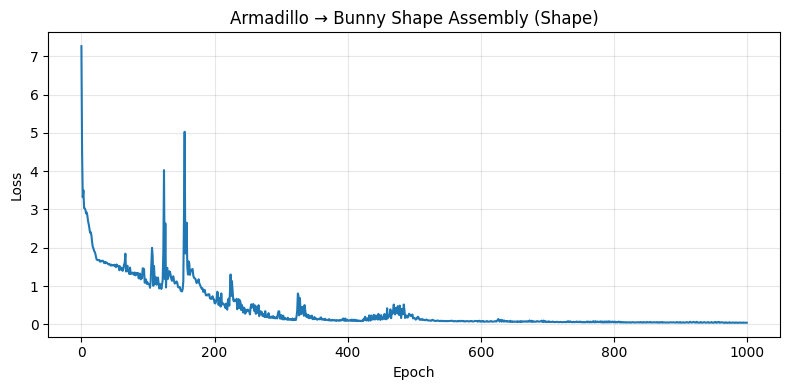

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses_shape)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Armadillo → Bunny Shape Assembly (Shape)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

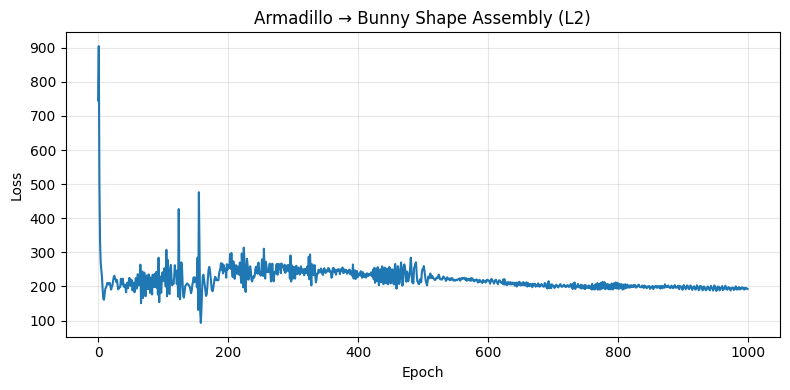

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses_l2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Armadillo → Bunny Shape Assembly (L2)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

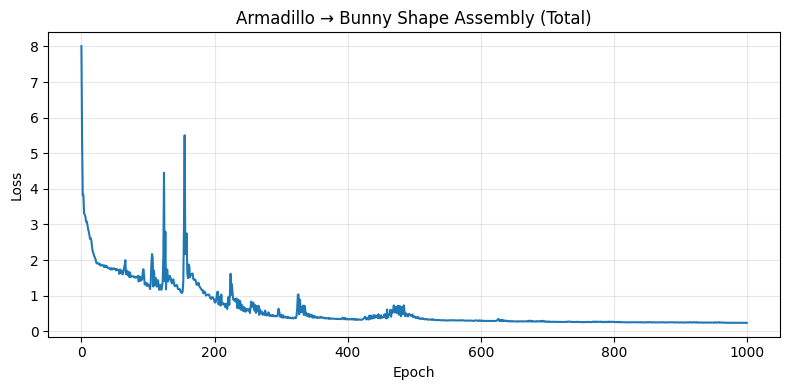

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Armadillo → Bunny Shape Assembly (Total)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Final rollout with trajectory capture

In [9]:
# Use the best trajectory captured during training
trajectory = best_trajectory
X_final = trajectory[-1]
print(f"Using best trajectory ({len(trajectory)} frames, best loss={best_loss:.4f})")

Using best trajectory (101 frames, best loss=0.2357)


## 7. Render final state (PyVista)

In [10]:
morph_final = np.full(N, 0.5, dtype=np.float32)

plotter = PyVistaInterface.draw_3d_view(
    X_final, rad_np[:N], morph_final, pol_np[:N],
    particle_count=N, blim=-6, tlim=6, alpha=0.9,
    show_polarities=False,
)
plotter.add_title("Predicted (Final)")
plotter.show()


2026-03-16 23:20:05.189 (2001.910s) [    154F1B48B740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## 8. Deformation movie (WarpMovieRenderer)

In [11]:
import os
from waxmorph.render import WarpMovieRenderer

os.makedirs("Output", exist_ok=True)
VIDEO_PATH = "Output/shape_assembly_jax.usd"

# Interpolate between trajectory keyframes for smoother video
# Should be used very carefully, can misrepresent results!
# Shouldn't change from 1 unless you know what this is doing 
INTERP_STEPS = 4

# Use uniform light blue coloring
colors_rgb = np.full((N, 3), [0.3, 0.6, 0.9], dtype=np.float32)

with WarpMovieRenderer(
    filename=VIDEO_PATH,
    max_particles=N,
    width=1920,
    height=1080,
    fps=30,
    device="cuda",
) as mov:
    frame_idx = 0
    for seg in trange(len(trajectory) - 1):
        start = trajectory[seg]
        end = trajectory[seg + 1]
        for sub in range(INTERP_STEPS):
            alpha = sub / INTERP_STEPS
            s = 3.0 * alpha**2 - 2.0 * alpha**3   # cubic interpolation
            pts = start * (1.0 - s) + end * s
            mov.write_frame_from_numpy(
                t=float(frame_idx),
                centers=pts,
                radii=rad_np[:N],
                colors=colors_rgb,
                particle_count=N,
            )
            frame_idx += 1
    # Write final frame a few extra times
    for _ in trange(15):
        mov.write_frame_from_numpy(
            t=float(frame_idx),
            centers=trajectory[-1],
            radii=rad_np[:N],
            colors=colors_rgb,
            particle_count=N,
        )
        frame_idx += 1

100%|█████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 1897.93it/s]

Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/MorphWARP/Output/shape_assembly_jax.usd`


In [31]:
G_current

np.float32(0.9960915)